In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

In [2]:
churn_data = pd.read_csv("Churn_Modelling.csv")

In [3]:
churn_data.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [4]:
churn_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [5]:
churn_data.isnull().sum()

RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

In [6]:
churn_data.drop(
    ['RowNumber', 'CustomerId', 'Surname'],
    axis=1,
    inplace=True
)

Label Encoding

In [7]:
label_encoder = LabelEncoder()

churn_data['Gender'] = label_encoder.fit_transform(
    churn_data['Gender']
)

One-Hot Encoding for Geography

In [8]:
churn_data = pd.get_dummies(
    churn_data,
    columns=['Geography'],
    drop_first=True
)

Data Visualization (EDA)

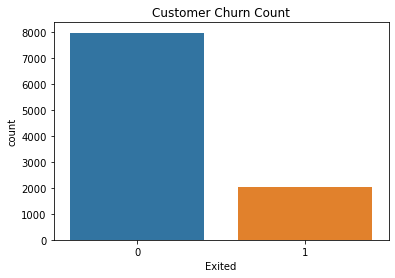

In [9]:
sns.countplot(x='Exited', data=churn_data)

plt.title("Customer Churn Count")

plt.show()

Age Distribution

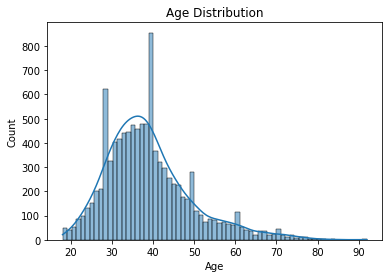

In [10]:
sns.histplot(churn_data['Age'], kde=True)

plt.title("Age Distribution")

plt.show()

Gender vs Churn

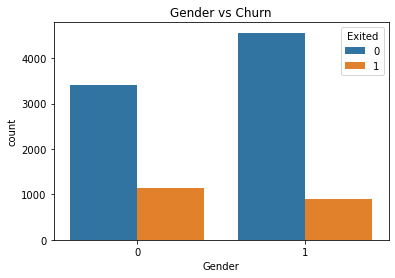

In [11]:
sns.countplot(
    x='Gender',
    hue='Exited',
    data=churn_data
)

plt.title("Gender vs Churn")

plt.show()

Define Features and Target

In [12]:
X = churn_data.drop('Exited', axis=1)

y = churn_data['Exited']

Split Dataset

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [15]:
model = RandomForestClassifier()

model.fit(X_train, y_train)

RandomForestClassifier()

In [16]:
y_pred = model.predict(X_test)

In [17]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.867


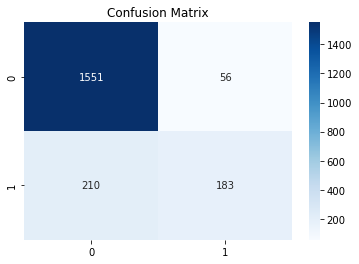

In [18]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Confusion Matrix")

plt.show()

In [19]:
importance = model.feature_importances_

feature_names = X.columns

feature_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importance
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

print(feature_importance)

              Feature  Importance
2                 Age    0.237972
8     EstimatedSalary    0.144914
4             Balance    0.142064
0         CreditScore    0.141098
5       NumOfProducts    0.132419
3              Tenure    0.082351
7      IsActiveMember    0.041473
9   Geography_Germany    0.026074
6           HasCrCard    0.019288
1              Gender    0.018372
10    Geography_Spain    0.013975


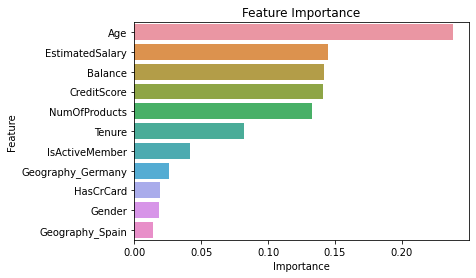

In [20]:
sns.barplot(
    x='Importance',
    y='Feature',
    data=feature_importance
)

plt.title("Feature Importance")

plt.show()